# 2eme Approche

**Objectif** : proposer $h_d$ qui minimise le risque de surverse, c'est-à-dire $h_d$ = min P(S>0). 
Comme en cours, on va poser la fonction $G(X)$, qui sépare l'état de sécurité et l'état de faillite (l'eau $Z_c$ est supérieur à la côte de la digue $Z_d$ ). 

Donc:
- $G(X) > 0$: sécurité
- $G(X) \le 0$: défaillance

Notre objectif est de calculer la probabilité de défaillance qu'on appelle ($P_f$):$$P_f = P(G(X) \le 0) = P(S \ge 0) = P(Z_c \ge Z_d)$$

Nous avons un modèle hydraulique à disposition, selon lequel on peut calculer 
$$H = \left(\frac{Q}{K_s \sqrt{\frac{Z_m - Z_v}{L}} B}\right)^{3/5}$$
Et alors
$$Z_c = Z_v + H$$
$$Z_d = h_d - Z_b$$

L'inconnu est $h_d$, on peut simuler des observations des variables considérées aléatoires ( $Q$, $K_s$, $Z_v$, $Z_m$) et on a des constantes (L, B, $Z_b$).

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.stats import gumbel_r, norm, triang
from scipy.optimize import brentq
from scipy.optimize import minimize

## Les constantes du problème

In [2]:
L = 5000 #Longueur du cours d'eau en m
B = 300 #Largeur du cours d'eau en m
Zb = 55.5 #Cote de la berge en m
N = 10000 # nombre de simulations pour monte carlo

## Les variables aléatoires du problème

In [3]:
# Générateur aléatoire 
rng = np.random.default_rng(123)

# Q ~ Gumbel(mode=1013, échelle=558)
Q_dist = gumbel_r(loc=1013, scale=558)

# Ks ~ Normal(mu=30, sigma=7.5)
Ks_dist = norm(loc=30, scale=7.5)

# Zv ~ Triangulaire symétrique sur [50-1, 50+1] avec mode au centre
a_Zv, b_Zv, mode_Zv = 49, 51, 50
c_Zv = (mode_Zv - a_Zv) / (b_Zv - a_Zv)  # ici 0.5 (symétrique)
Zv_dist = triang(c=c_Zv, loc=a_Zv, scale=(b_Zv - a_Zv))

# Zm ~ Triangulaire symétrique sur [55-1, 55+1] avec mode au centre
a_Zm, b_Zm, mode_Zm = 54, 56, 55
c_Zm = (mode_Zm - a_Zm) / (b_Zm - a_Zm)  # ici 0.5 (symétrique)
Zm_dist = triang(c=c_Zm, loc=a_Zm, scale=(b_Zm - a_Zm))

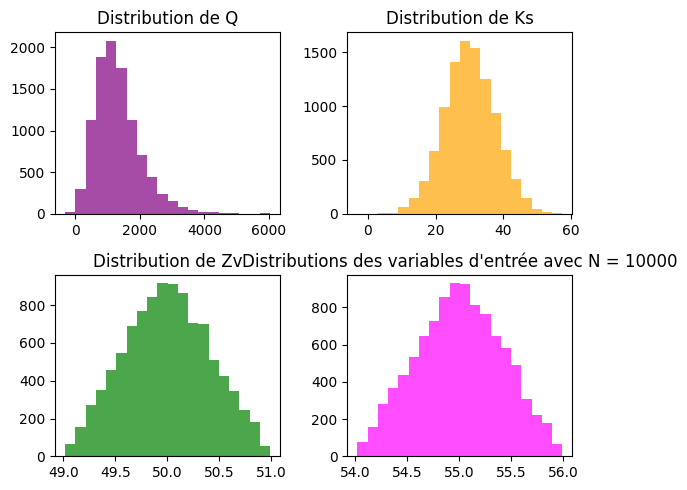

In [4]:
Q_samples  = Q_dist.rvs(size=N, random_state=rng)
Ks_samples = Ks_dist.rvs(size=N, random_state=rng)
Zv_samples = Zv_dist.rvs(size=N, random_state=rng)
Zm_samples = Zm_dist.rvs(size=N, random_state=rng)

# plot ces 4 variables pour voir si leur distribution correspond à ce qu'on attend
fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs[0, 0].hist(Q_samples, bins=20, color='purple', alpha=0.7)
axs[0, 0].set_title(f'Distribution de Q')
axs[0, 1].hist(Ks_samples, bins=20, color='orange', alpha=0.7)
axs[0, 1].set_title('Distribution de Ks')
axs[1, 0].hist(Zv_samples, bins=20, color='green', alpha=0.7)
axs[1, 0].set_title('Distribution de Zv')
axs[1, 1].hist(Zm_samples, bins=20, color='magenta', alpha=0.7)
axs[1, 1].set_title('Distribution de Zm')
plt.tight_layout()
plt.title(f'Distributions des variables d\'entrée avec N = {N}')
plt.show()

# Modèle hydraulique

In [5]:
# J = (Zm - Zv) / L
J = (Zm_samples - Zv_samples) / L
J = np.maximum(J, 0) # pas de distances négatives

# calcul de H
H = (Q_samples / (Ks_samples * np.sqrt(J) * B ) ) ** (3/5)

Zc = Zv_samples + H

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_81322/2862232106.py:6: RuntimeWarning: invalid value encountered in power
  H = (Q_samples / (Ks_samples * np.sqrt(J) * B ) ) ** (3/5)


## Solution 1: Monte Carlo "à la main"

- On choisit une liste de valeurs arbitraires de hauteurs de digue (0.1 m à 3 m par pas de 0.1 m).

- On calcule la probabilité de défaillance : Pour chaque hauteur, on compte combien de simulations Monte Carlo ont une hauteur d'eau ($Zc$) qui dépasse la côte de la digue ($Zd$), en estimant $P_f \approx \frac{\text{Nombre d'erreurs}}{N}$. Et, pour chaque calcul, on donne l'indice de fiabilité : On transforme chaque $P_f$ en indice de fiabilité $β = -Φ⁻¹(Pf)$ où $Φ$ est la fonction de répartition normale.

- On stocke tous les résultats dans un dataframe et on choisit la valeur de $h_d$ pour atteindre un risque cible (ex: $P_f = 0.001$).

- On a choisi de tracer la courbe $P_f$ vs $h_d$ à échelle logarithmique pour bien retrouver le pattern espéré: plus on construit une digue élevée, moindre est le risque. 

Hauteur (m) | Proportion d'erreurs | Indice de fiabilité (Beta)
0.100       | 0.00840              | 2.39
0.200       | 0.00780              | 2.42
0.300       | 0.00710              | 2.45
0.400       | 0.00640              | 2.49
0.500       | 0.00540              | 2.55
0.600       | 0.00480              | 2.59
0.700       | 0.00440              | 2.62
0.800       | 0.00380              | 2.67
0.900       | 0.00340              | 2.71
1.000       | 0.00310              | 2.74
1.100       | 0.00270              | 2.78
1.200       | 0.00240              | 2.82
1.300       | 0.00200              | 2.88
1.400       | 0.00200              | 2.88
1.500       | 0.00180              | 2.91
1.600       | 0.00170              | 2.93
1.700       | 0.00150              | 2.97
1.800       | 0.00120              | 3.04
1.900       | 0.00110              | 3.06
2.000       | 0.00090              | 3.12
2.100       | 0.00080              | 3.16
2.200       | 0.00080              | 3.16
2.300       

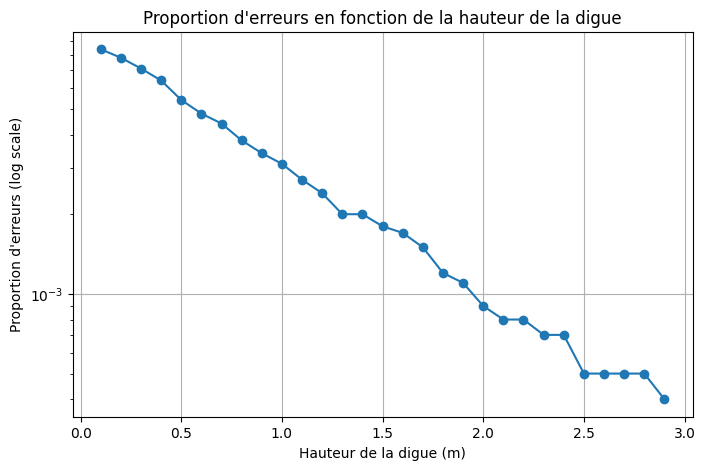

Hauteur de digue pour un risque de 0.001 : 2.00 m


In [6]:
hauteurs_digue = [i*0.1 for i in range(1, 30)] # de 0.1 m à 3 m par pas de 0.1 m
print("Hauteur (m) | Proportion d'erreurs | Indice de fiabilité (Beta)")

res = []
for hd in hauteurs_digue:
    zd = Zb + hd  
    # G(X) = Zd - Zc
    fails = np.sum(Zc > zd)
    pf = fails / N
    
    # (Beta = -Phi^-1(Pf))
    if pf > 0 and pf < 1:
        beta = -stats.norm.ppf(pf)
    else:
        beta = np.nan
    
    res.append([hd, pf, beta])
    print(f"{hd:.3f}       | {pf:.5f}              | {beta:.2f}")

# convertir res en dataframe pour plot
df_res = pd.DataFrame(res, columns=['Hauteur (m)', 'Proportion d\'erreurs', 'Indice de fiabilité (Beta)'])
plt.figure(figsize=(8, 5))
plt.plot(df_res['Hauteur (m)'], df_res['Proportion d\'erreurs'], marker='o')
plt.yscale('log')
plt.xlabel('Hauteur de la digue (m)')
plt.ylabel('Proportion d\'erreurs (log scale)')
plt.title('Proportion d\'erreurs en fonction de la hauteur de la digue')
plt.grid()
plt.show()

# Hauteur pour laquelle le risque est de 0.001 (Pf = 0.001)
target_pf = 0.001
hd_target = df_res[df_res['Proportion d\'erreurs'] <= target_pf]['Hauteur (m)'].min()
print(f"Hauteur de digue pour un risque de 0.001 : {hd_target:.2f} m")

## Solution 2: Monte Carlo quantile

Dans cette partie on se propose d'inverser la question, au lieu de demander "Pour ce $h_d$, quelle est la proba de défaillance?", on va se demander "Sachant cette distribution, quel $h_d$ j'ai besoin pour que dans X% des cas on n'ait pas de défaillance?".
Comme
$$S > 0 \iff Z_c > Z_d  \iff Z_v + H > h_d + Z_b \iff h_d > Z_v + H - Z_b$$
Alors $$P_f = P( h_d > Z_v + H - Z_b)$$
Appelons $Y = Z_v + H - Z_b$ . Alors Y est une variable aléatoire, on va calculer sa fonction de répartition empirique, en ordonnant les valeurs de Y de manière croissante puis on va chercher le $h_d$ pour lequel $P_f = P(Y < h_d) < 1- risque$. En pratique, on choisit l'indice de l'array qui laisse de côté $risque$ données dans les valeurs ordonnées de Y. 

In [7]:
Y = Zc - Zb
risque = 0.001
confiance = 1 - risque # 0.999
# drop les Nan de Y
Y = Y[~np.isnan(Y)]
Y_sorted = np.sort(Y)

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_81322/3018815090.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Proba cumulée $F(x) = P(X \leq x)$')


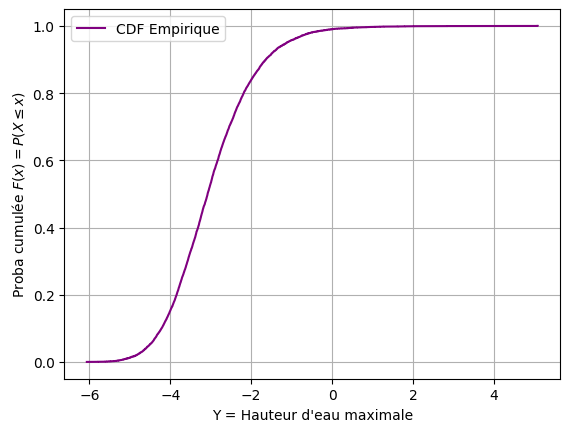

Hauteur pour avoir 99.9% de chances de ne pas avoir une innondation en 9976 ans: 1.9794 m.


In [8]:
# Tracer la fonction de répartition empirique de Y
plt.step(Y_sorted, np.arange(1, len(Y)+1) / len(Y), where='post', label='CDF Empirique', color='purple')

plt.xlabel("Y = Hauteur d'eau maximale")
plt.ylabel('Proba cumulée $F(x) = P(X \leq x)$')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

indice = int(confiance * len(Y))
hd_manual = Y_sorted[indice]

print(f"Hauteur pour avoir {confiance*100}% de chances de ne pas avoir une innondation en {len(Y)} ans: {hd_manual:.4f} m.")

## Solution 3: FORM

Contrairement à Monte Carlo, FORM calcule la probabilité de défaillance $P_f$ pour un $h_d$ fixe.

Implémentation:
- Transformation de l'espace : On transforme les variables aléatoires physiques (Q, Ks, Zv, Zm) en variables normales standard (U) en utilisant leurs fonctions de distribution.
- Indice de fiabilité $\beta$ : On cherche la distance minimale entre l'origine et la surface de défaillance G(u) = 0 dans l'espace normal standard.
- Calcul de Pf : Une fois β trouvé, la probabilité de défaillance est donnée par:
$P_f = Φ(−β)$ où Φ est la fonction de répartition normale.
- Recherche de hd optimal : On cherche la hauteur de digue hd qui correspond à un β (et donc une $P_f$) cible en résolvant une équation non-linéaire.

In [9]:
# Passer de U (normale std) à l'espace physique
def transform_u_to_x(u):
    # u est un vecteur de 4 éléments [u_Q, u_Ks, u_Zv, u_Zm]
    
    # Q: Gumbel (mode=1013, scale=558)
    # F_Q(x) = Phi(u) -> x = F_Q^-1(Phi(u))
    q = gumbel_r.ppf(norm.cdf(u[0]), loc=1013, scale=558)
    
    # Ks: Normal (mu=30, sigma=7.5)
    # x = mu + u*sigma
    ks = 30 + u[1] * 7.5
    
    # Zv: Triangulaire (min=49, mode=50, max=51)
    # F_Zv(x) = Phi(u) -> x = F_Zv^-1(Phi(u))
    zv = triang.ppf(norm.cdf(u[2]), c=0.5, loc=49, scale=2)
    
    # Zm: Triangulaire (min=54, mode=55, max=56)
    zm = triang.ppf(norm.cdf(u[3]), c=0.5, loc=54, scale=2)
    
    return np.array([q, ks, zv, zm])

# Définir la fonction d'état limite G(u, hd)
def limit_state_function(u, hd):
    # Nous transformons dans l'espace physique
    x = transform_u_to_x(u)
    q, ks, zv, zm = x[0], x[1], x[2], x[3]
      
    # Modèle hydraulique
    pente = (zm - zv) / L
    if pente <= 0: 
        return -999  # Pénalisation physique
    
    H = (q / (ks * B * np.sqrt(pente)))**(0.6)
    
    # G(X) = Hauteur digue - Niveau eau
    # Si G < 0 -> Défaillance
    S = zv + H - Zb
    return hd - S

# Algorithme FORM pour trouver beta donné un hd
# L'indice beta est la distance minimale depuis l'origine jusqu'à la surface G(u)=0

def calculate_beta_form(hd):
    # On veut minimiser la distance ||u|| sous la contrainte G(u) = 0
    # Équivaut à minimiser ||u||^2
    
    fun_obj = lambda u: np.dot(u, u)  # Norme au carré
    
    # Contrainte : G(u) = 0
    cons = ({'type': 'eq', 'fun': lambda u: limit_state_function(u, hd)})
    
    # Point initial (u=0 est la moyenne)
    u0 = np.zeros(4)
    
    # Optimisation
    res = minimize(fun_obj, u0, constraints=cons, method='SLSQP')
    
    dist_beta = np.sqrt(res.fun)
    
    # Signe de beta : si G(0) < 0, on est en zone de défaillance -> beta négatif
    if limit_state_function(u0, hd) < 0:
        dist_beta = -dist_beta
    return dist_beta, res.x  # On retourne aussi le point u* trouvé

# Trouver hd pour un risque cible (FORM Inverse)
def find_hd_form(target_prob):
    l = []
    target_beta = -norm.ppf(target_prob)
    print(f"Recherche de hd pour Pf = {target_prob} (Beta = {target_beta:.4f})...")
    
    # Fonction racine : beta_calcule(hd) - beta_objectif = 0
    def objective(h):
        beta_calc, _ = calculate_beta_form(h)
        l.append(_)
        return (beta_calc - target_beta)

    try:
        hd_optimal = brentq(objective, 0, 10)
    except ValueError:
        print("Erreur : l'intervalle 0-10m ne contient pas la solution ou erreur numérique.")
        return None
        
    return hd_optimal, beta, l[-1]  # On retourne aussi le point u* trouvé pour le hd optimal


In [10]:
risque_objet = 1e-3  # 0.001
hd_form, beta, u_star = find_hd_form(risque_objet)

print(f"\nRÉSULTAT FORM")
print(f"Hauteur optimale de la digue : {hd_form:.4f} m")

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_81322/2622860419.py:33: RuntimeWarning: invalid value encountered in scalar power
  H = (q / (ks * B * np.sqrt(pente)))**(0.6)


Recherche de hd pour Pf = 0.001 (Beta = 3.0902)...

RÉSULTAT FORM
Hauteur optimale de la digue : 1.9172 m


Point u*: [ 1.63451295 -2.55448353  0.56259651 -0.16678287]
Indice Beta: 3.0889
Proba de défaillance: 1.0045e-03


<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_81322/1675259105.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.clabel(contours, inline=True, fontsize=8, fmt='%1.0f $\sigma$')
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_81322/2622860419.py:33: RuntimeWarning: invalid value encountered in scalar power
  H = (q / (ks * B * np.sqrt(pente)))**(0.6)


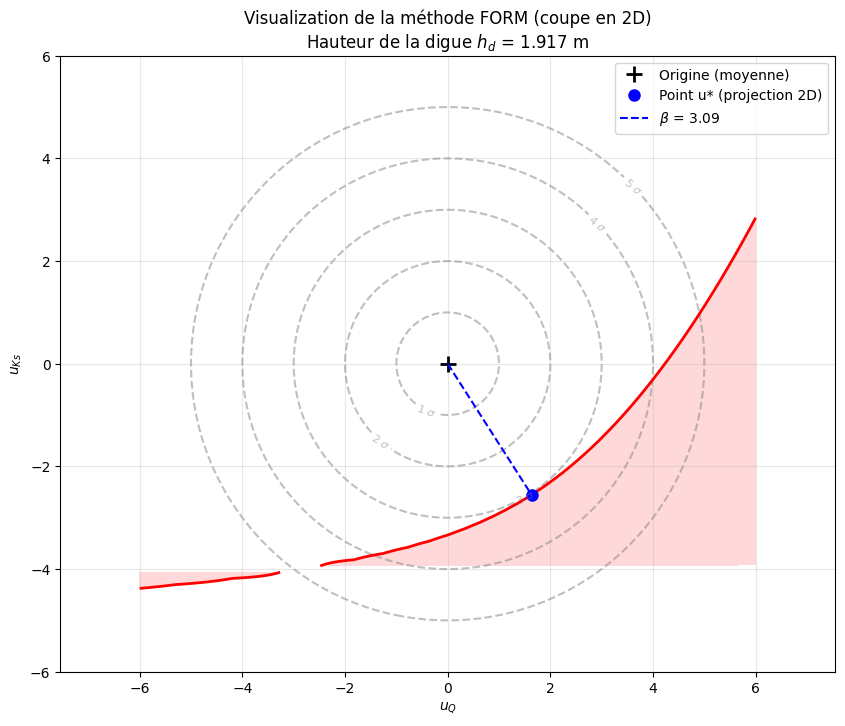

In [11]:
beta = np.linalg.norm(u_star)
pf_form = norm.cdf(-beta)

print(f"Point u*: {u_star}")
print(f"Indice Beta: {beta:.4f}")
print(f"Proba de défaillance: {pf_form:.4e}")

# Visu 2D (Coupe dans le plan Q - Ks)
# On fixe (Zv, Zm) en leur valeurs dans le point u*
def limit_state_2d_slice(uq, uks):
    # On crée un vecteur u complet utilisant les valeurs fixes Zv y Zm
    u_full = np.array([uq, uks, u_star[2], u_star[3]])
    return limit_state_function(u_full, hd_form)

grid_range = max(6.0, beta + 1) # Rang dynamique en dépendant de beta
x = np.linspace(-grid_range, grid_range, 100)
y = np.linspace(-grid_range, grid_range, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# Calculer G(u) pour chaque point de la maille
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = limit_state_2d_slice(X[i, j], Y[i, j])

plt.figure(figsize=(10, 8))
#Contours de proba
R = np.sqrt(X**2 + Y**2)
contours = plt.contour(X, Y, R, levels=[1, 2, 3, 4, 5], colors='gray', linestyles='dashed', alpha=0.5)
plt.clabel(contours, inline=True, fontsize=8, fmt='%1.0f $\sigma$')

# Fill la zone de défaillance (G < 0)
plt.contourf(X, Y, Z, levels=[-100, 0], colors=['red'], alpha=0.15)
plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=2)

# Origine
plt.plot(0, 0, 'k+', markersize=12, markeredgewidth=2, label='Origine (moyenne)')
# u* (projection en 2D)
plt.plot(u_star[0], u_star[1], 'bo', markersize=8, label='Point u* (projection 2D)')
# Beta
plt.plot([0, u_star[0]], [0, u_star[1]], 'b--', label=f'$\\beta$ = {beta:.2f}')

plt.xlabel('$u_Q$')
plt.ylabel('$u_{Ks}$')
plt.title(f'Visualization de la méthode FORM (coupe en 2D)\nHauteur de la digue $h_d$ = {hd_form:.4} m')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.show()

### **Comparaison des Solutions 1 2 et 3**
Les trois méthodes sont cohérentes :
| | 100 simulations | 10 000 simulations|
|----|---|---|
|Solution 1 (Monte Carlo manuel)|$h_d \approx 1.9 m$|$h_d \approx 2.0 m$|
|Solution 2 (Monte Carlo quantile)|$h_d \approx 1.8225 m$|$h_d \approx 1.9794 m$|
|Solution 3 (FORM)||$h_d \approx 1.9219 m$|


L'écar de quelques centimètres entre chaque solution est dû au fait que la Solution 1 itère sur des valeurs discrètes, d'où les résultats arrondis.

Avec ces 100 simulations représentant 100 années, cette hauteur de digue correspond à un niveau de sécurité tel qu'on aurait en moyenne **aucune inondation au cours du siècle** pour un niveau de confiance de 99.9%.

Pour 10 000 simulations, les deux approches convergent vers la même conclusion : pour garantir un niveau de sécurité de 99.9% (risque de 0.001), il faut construire une digue d'environ 2.0 mètres. Cependant, simuler 10 000 années n'est pas réaliste ici., les résultats avec N=100 sont plus pertinents d'un point de vue ingénierie et explicabilité.

FORM donne une hauteur légèrement plus faible que MC ici : dû au fait que FORM linéarise la surface de rupture dans l'espace normalisé (approximation de premier ordre). Selon la non‑linéarité du modèle hydraulique et la queue des distributions, FORM peut sous/over‑estimer légèrement Pf. Cependant, avec FORM on peut pourrait jouer avec u_star et voir la contribution.